# Tox21 Training and Evaluation

Train one XGBoost binary classifier per assay using assay-specific non-NaN labels, evaluate performance, save artifacts, and run an end-to-end inference sanity check.

## Cell 1 - Imports and Config

In [9]:
import numpy as np
import pandas as pd
import joblib
import json
import os
import time
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

ASSAY_COLUMNS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
    'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]
MODELS_DIR = '../trained_models/'
os.makedirs(MODELS_DIR, exist_ok=True)
RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

## Cell 2 - Load Data

In [10]:
X = np.load('../processed/X_processed.npy')
y = pd.read_parquet('../processed/y_labels.parquet')
with open('../processed/feature_names.json', 'r', encoding='utf-8') as f:
    feature_names = json.load(f)
print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (7831, 2068), y shape: (7831, 12)


## Cell 3 - Training Loop

In [11]:
results = []
trained_models = {}
model_registry = {}
training_start = time.time()

for assay in ASSAY_COLUMNS:
    valid_mask = ~y[assay].isna()
    X_assay = X[valid_mask.values]
    y_assay = y.loc[valid_mask, assay].astype(int)

    positive_count = int((y_assay == 1).sum())
    negative_count = int((y_assay == 0).sum())

    if positive_count == 0:
        print(f'WARN {assay}: skipped (no positive examples).')
        continue

    if negative_count == 0:
        print(f'WARN {assay}: skipped (no negative examples).')
        continue

    if min(positive_count, negative_count) < 2:
        print(f'WARN {assay}: skipped (insufficient class samples for stratified split).')
        continue

    scale_pos_weight = negative_count / positive_count

    X_train, X_test, y_train, y_test = train_test_split(
        X_assay,
        y_assay,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_assay
    )

    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc_auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    n_train = len(X_train)
    n_positive = int(y_assay.sum())

    model_filename = f'model_{assay}.joblib'
    model_path = f'{MODELS_DIR}{model_filename}'
    joblib.dump(model, model_path)

    trained_models[assay] = model
    model_registry[assay] = model_filename

    results.append({
        'assay': assay,
        'roc_auc': roc_auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'n_train': n_train,
        'n_positive': n_positive,
        'scale_pos_weight': scale_pos_weight
    })

    print(
        f'OK {assay} | ROC-AUC: {roc_auc:.3f} | F1: {f1:.3f} | '
        f'n_train: {n_train} | pos_weight: {scale_pos_weight:.2f}'
    )

training_elapsed = time.time() - training_start
print(f'\nTraining completed in {training_elapsed:.1f} seconds. Trained models: {len(results)}')

OK NR-AR | ROC-AUC: 0.759 | F1: 0.449 | n_train: 5812 | pos_weight: 22.51
OK NR-AR-LBD | ROC-AUC: 0.799 | F1: 0.590 | n_train: 5406 | pos_weight: 27.51
OK NR-AhR | ROC-AUC: 0.899 | F1: 0.612 | n_train: 5239 | pos_weight: 7.53
OK NR-Aromatase | ROC-AUC: 0.876 | F1: 0.514 | n_train: 4656 | pos_weight: 18.40
OK NR-ER | ROC-AUC: 0.690 | F1: 0.414 | n_train: 4954 | pos_weight: 6.81
OK NR-ER-LBD | ROC-AUC: 0.807 | F1: 0.469 | n_train: 5564 | pos_weight: 18.87
OK NR-PPAR-gamma | ROC-AUC: 0.856 | F1: 0.381 | n_train: 5160 | pos_weight: 33.68
OK SR-ARE | ROC-AUC: 0.853 | F1: 0.562 | n_train: 4665 | pos_weight: 5.19
OK SR-ATAD5 | ROC-AUC: 0.876 | F1: 0.420 | n_train: 5657 | pos_weight: 25.79
OK SR-HSE | ROC-AUC: 0.790 | F1: 0.389 | n_train: 5173 | pos_weight: 16.38
OK SR-MMP | ROC-AUC: 0.938 | F1: 0.691 | n_train: 4648 | pos_weight: 5.33
OK SR-p53 | ROC-AUC: 0.873 | F1: 0.404 | n_train: 5419 | pos_weight: 15.01

Training completed in 23.8 seconds. Trained models: 12


## Cell 4 - Results Table

In [12]:
results_df = pd.DataFrame(results, columns=[
    'assay', 'roc_auc', 'f1', 'precision', 'recall', 'n_train', 'n_positive', 'scale_pos_weight'
])

if results_df.empty:
    raise ValueError('No models were trained. Check labels and class balance for each assay.')

results_df = results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['roc_auc', 'f1']))

mean_auc = results_df['roc_auc'].mean()
best_row = results_df.iloc[0]
worst_row = results_df.iloc[-1]

print(
    f"Mean ROC-AUC: {mean_auc:.3f} | "
    f"Best: {best_row['assay']} ({best_row['roc_auc']:.3f}) | "
    f"Worst: {worst_row['assay']} ({worst_row['roc_auc']:.3f})"
)

results_df.to_csv('../processed/model_evaluation.csv', index=False)
print('Saved: ../processed/model_evaluation.csv')

,assay,roc_auc,f1,precision,recall,n_train,n_positive,scale_pos_weight
0,SR-MMP,0.937706,0.691293,0.671795,0.711957,4648,918,5.328976
1,NR-AhR,0.899396,0.611898,0.542714,0.701299,5239,768,7.527344
2,NR-Aromatase,0.875943,0.513761,0.571429,0.466667,4656,300,18.403333
3,SR-ATAD5,0.875544,0.420000,0.446809,0.396226,5657,264,25.787879
4,SR-p53,0.872506,0.404372,0.377551,0.435294,5419,423,15.014184
5,NR-PPAR-gamma,0.856151,0.380952,0.461538,0.324324,5160,186,33.677419
6,SR-ARE,0.852661,0.562500,0.513158,0.622340,4665,942,5.191083
7,NR-ER-LBD,0.807332,0.468750,0.517241,0.428571,5564,350,18.871429
8,NR-AR-LBD,0.799478,0.589744,0.741935,0.489362,5406,237,27.514768
9,SR-HSE,0.789654,0.388889,0.400000,0.378378,5173,372,16.384409


Mean ROC-AUC: 0.835 | Best: SR-MMP (0.938) | Worst: NR-ER (0.690)
Saved: ../processed/model_evaluation.csv


## Cell 5 - ROC-AUC Bar Chart

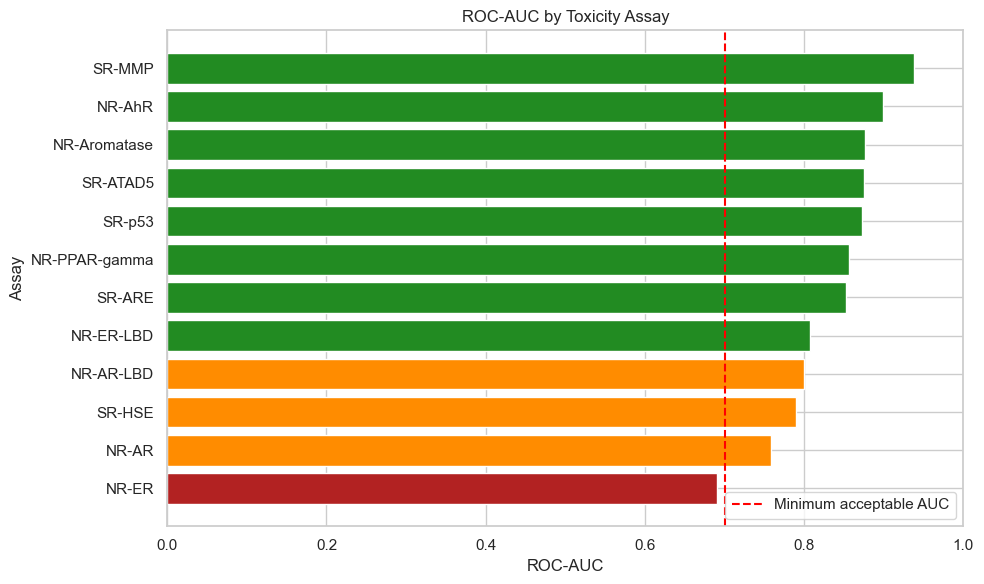

Saved: ../../../docs/model_performance.png


In [13]:
plot_df = results_df.sort_values('roc_auc', ascending=True)

bar_colors = [
    'forestgreen' if auc >= 0.8 else ('darkorange' if auc >= 0.7 else 'firebrick')
    for auc in plot_df['roc_auc']
]

plt.figure(figsize=(10, 6))
plt.barh(plot_df['assay'], plot_df['roc_auc'], color=bar_colors)
plt.axvline(x=0.7, color='red', linestyle='--', linewidth=1.5, label='Minimum acceptable AUC')
plt.xlim(0.0, 1.0)
plt.xlabel('ROC-AUC')
plt.ylabel('Assay')
plt.title('ROC-AUC by Toxicity Assay')
plt.legend(loc='lower right')
plt.tight_layout()

docs_dir = '../../../docs'
os.makedirs(docs_dir, exist_ok=True)
performance_plot_path = f'{docs_dir}/model_performance.png'
plt.savefig(performance_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {performance_plot_path}')

## Cell 6 - Feature Importance Analysis

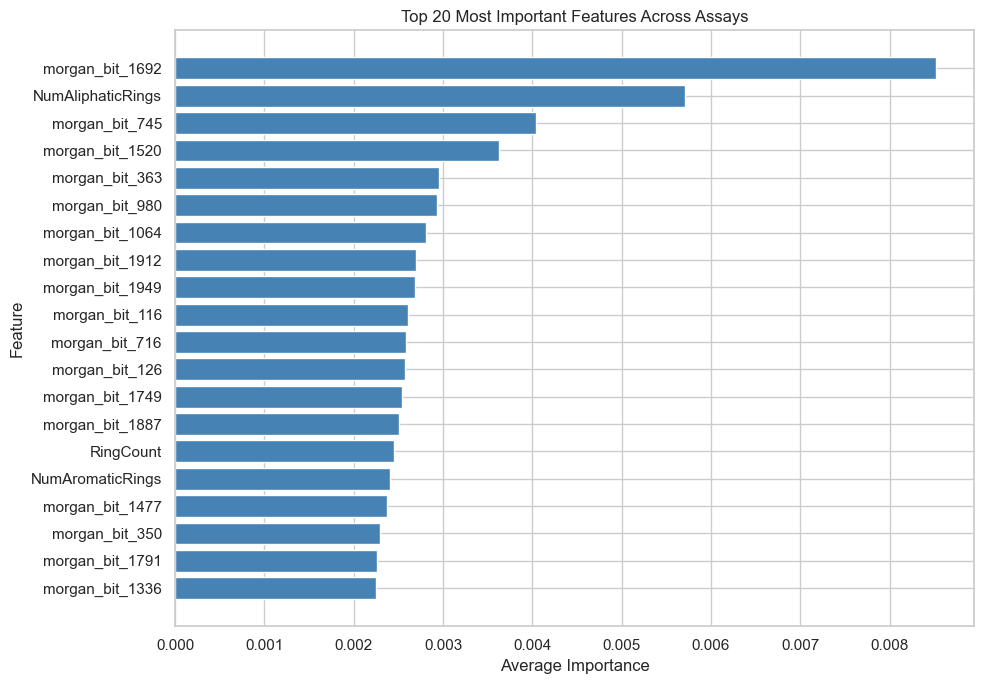

Saved: ../../../docs/feature_importance.png

Top 5 features by average importance:
- morgan_bit_1692: 0.008520
- NumAliphaticRings: 0.005710
- morgan_bit_745: 0.004036
- morgan_bit_1520: 0.003623
- morgan_bit_363: 0.002956


In [14]:
importance_vectors = []

for assay in ASSAY_COLUMNS:
    model_filename = model_registry.get(assay)
    if model_filename is None:
        continue

    model_path = f'{MODELS_DIR}{model_filename}'
    if not os.path.exists(model_path):
        continue

    model = trained_models.get(assay)
    if model is None:
        model = joblib.load(model_path)

    importance_vectors.append(model.feature_importances_)

if not importance_vectors:
    raise ValueError('No trained models available for feature importance analysis.')

mean_importance = np.mean(np.vstack(importance_vectors), axis=0)

if len(feature_names) != len(mean_importance):
    print('WARN: feature_names length mismatch. Falling back to generic names.')
    feature_names = [f'feature_{i}' for i in range(len(mean_importance))]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_importance
}).sort_values('importance', ascending=False)

top20 = importance_df.head(20).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top20['feature'], top20['importance'], color='steelblue')
plt.xlabel('Average Importance')
plt.ylabel('Feature')
plt.title('Top 20 Most Important Features Across Assays')
plt.tight_layout()

feature_plot_path = '../../../docs/feature_importance.png'
os.makedirs('../../../docs', exist_ok=True)
plt.savefig(feature_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {feature_plot_path}')

top5 = importance_df.head(5)
print('\nTop 5 features by average importance:')
for _, row in top5.iterrows():
    print(f"- {row['feature']}: {row['importance']:.6f}")

## Cell 7 - Save Model Registry

In [15]:
if not model_registry:
    model_registry = {
        assay: f'model_{assay}.joblib'
        for assay in ASSAY_COLUMNS
        if os.path.exists(f'{MODELS_DIR}model_{assay}.joblib')
    }

registry_path = '../processed/model_registry.json'
with open(registry_path, 'w', encoding='utf-8') as f:
    json.dump(model_registry, f, indent=2)

print(f'Saved model registry with {len(model_registry)} entries: {registry_path}')
model_registry

Saved model registry with 12 entries: ../processed/model_registry.json


{'NR-AR': 'model_NR-AR.joblib',
 'NR-AR-LBD': 'model_NR-AR-LBD.joblib',
 'NR-AhR': 'model_NR-AhR.joblib',
 'NR-Aromatase': 'model_NR-Aromatase.joblib',
 'NR-ER': 'model_NR-ER.joblib',
 'NR-ER-LBD': 'model_NR-ER-LBD.joblib',
 'NR-PPAR-gamma': 'model_NR-PPAR-gamma.joblib',
 'SR-ARE': 'model_SR-ARE.joblib',
 'SR-ATAD5': 'model_SR-ATAD5.joblib',
 'SR-HSE': 'model_SR-HSE.joblib',
 'SR-MMP': 'model_SR-MMP.joblib',
 'SR-p53': 'model_SR-p53.joblib'}

## Cell 8 - Sanity Check Prediction

In [16]:
import sys
sys.path.append('../../../backend')
from app.services.mol_processor import extract_features

test_smiles = 'CC(=O)Oc1ccccc1C(=O)O'  # aspirin
features = extract_features(test_smiles)

if features is None:
    raise ValueError('Feature extraction failed for test SMILES.')

print(f'Feature vector shape: {features.shape}')

for assay in ASSAY_COLUMNS:
    model_filename = model_registry.get(assay, f'model_{assay}.joblib')
    model_path = f'{MODELS_DIR}{model_filename}'

    if not os.path.exists(model_path):
        print(f'{assay}: model not available (skipped)')
        continue

    model = joblib.load(model_path)
    prob = model.predict_proba(features.reshape(1, -1))[0, 1]
    pred = 'TOXIC' if prob > 0.5 else 'SAFE'
    print(f'{assay}: {pred} ({prob:.3f})')

print('\nComment: Aspirin should be mostly SAFE across assays; this checks end-to-end pipeline health.')

Feature vector shape: (2068,)
NR-AR: SAFE (0.332)
NR-AR-LBD: SAFE (0.004)
NR-AhR: SAFE (0.011)
NR-Aromatase: SAFE (0.074)
NR-ER: SAFE (0.326)
NR-ER-LBD: SAFE (0.216)
NR-PPAR-gamma: SAFE (0.022)
SR-ARE: TOXIC (0.598)
SR-ATAD5: SAFE (0.029)
SR-HSE: SAFE (0.077)
SR-MMP: TOXIC (0.810)
SR-p53: SAFE (0.478)

Comment: Aspirin should be mostly SAFE across assays; this checks end-to-end pipeline health.
